# Run 4 — Fine-tuning CamemBERT
## DEFT2013 Tache 2 — Classification de recettes

In [14]:
!pip install -q transformers datasets evaluate accelerate scikit-learn sentencepiece

In [15]:
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from datasets import Dataset
from transformers import (
    CamembertTokenizer,
    CamembertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from google.colab import files

print("Imports OK")
print(f"GPU disponible : {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("ATTENTION : pas de GPU ! Va dans Runtime -> Change runtime type -> T4 GPU")

Imports OK
GPU disponible : True


In [16]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print(f"Train : {len(train)} recettes")
print(f"Test  : {len(test)} recettes")

assert len(train) == 12473, f"ERREUR train incomplet : {len(train)} lignes"
assert len(test)  == 1388,  f"ERREUR test incomplet : {len(test)} lignes"
print("Dataset OK")

Train : 12473 recettes
Test  : 1388 recettes
Dataset OK


In [17]:
# Preprocessing : titre + ingredients (suffisant pour CamemBERT, evite troncature)
def clean_text(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def build_text(df):
    return (
        "Titre: " + df["titre"].fillna("").astype(str) +
        " Ingredients: " + df["ingredients"].fillna("").astype(str) +
        " Recette: " + df["recette"].fillna("").astype(str).str[:200]
    ).apply(clean_text)

train["text"] = build_text(train)
test["text"]  = build_text(test)

# Labels
label2id = {"Entree": 0, "Plat principal": 1, "Dessert": 2}
id2label = {v: k for k, v in label2id.items()}

# Normaliser les accents dans les labels pour eviter les problemes
train["type_clean"] = train["type"].str.replace("Entrée", "Entree")
test["type_clean"]  = test["type"].str.replace("Entrée", "Entree")

train["label"] = train["type_clean"].map(label2id)
test["label"]  = test["type_clean"].map(label2id)

print("Labels OK")
print(train[["type", "label"]].value_counts())

Labels OK
type            label
Plat principal  1        5802
Dessert         2        3762
Entrée          0        2909
Name: count, dtype: int64


In [18]:
# Split train -> train (90%) + validation (10%)
train_df, val_df = train_test_split(
    train,
    test_size=0.1,
    random_state=42,
    stratify=train["label"]
)

print(f"Train  : {len(train_df)} recettes")
print(f"Val    : {len(val_df)} recettes")
print(f"Test   : {len(test)} recettes")

# Creer les datasets HuggingFace
train_dataset = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test[["text", "label"]].reset_index(drop=True))

print(train_dataset)
print(val_dataset)

Train  : 11225 recettes
Val    : 1248 recettes
Test   : 1388 recettes
Dataset({
    features: ['text', 'label'],
    num_rows: 11225
})
Dataset({
    features: ['text', 'label'],
    num_rows: 1248
})


In [19]:
# Tokenisation (une seule fois)
tokenizer = CamembertTokenizer.from_pretrained("camembert-base")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenisation OK")

Map:   0%|          | 0/11225 [00:00<?, ? examples/s]

Map:   0%|          | 0/1248 [00:00<?, ? examples/s]

Map:   0%|          | 0/1388 [00:00<?, ? examples/s]

Tokenisation OK


In [20]:
# Charger CamemBERT pour la classification
model = CamembertForSequenceClassification.from_pretrained(
    "camembert-base",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
print("Modele charge")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modele charge


In [21]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./camembert_recipe",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    per_device_train_batch_size=16,       # réduit pour gradient accumulation
    per_device_eval_batch_size=64,
    gradient_accumulation_steps=2,        # simule batch=32, plus de mises à jour
    num_train_epochs=5,                   # plus d'epochs
    learning_rate=1e-5,                   # LR plus doux
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer pret - lancement entrainement...")
trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer pret - lancement entrainement...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.409926,0.381323,0.870994,0.857218
2,0.733194,0.337882,0.875801,0.858121
3,0.614454,0.290457,0.885417,0.875834
4,0.553322,0.289157,0.884615,0.876483
5,0.520421,0.297282,0.883013,0.873138


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1755, training_loss=0.7662634259954817, metrics={'train_runtime': 635.5111, 'train_samples_per_second': 88.315, 'train_steps_per_second': 2.762, 'total_flos': 5486769364343022.0, 'train_loss': 0.7662634259954817, 'epoch': 5.0})

In [22]:
# Evaluation sur le jeu de test
pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = np.array(test["label"])

target_names = ["Entree", "Plat principal", "Dessert"]
f1  = f1_score(y_true, y_pred, average="macro")
acc = accuracy_score(y_true, y_pred)

print("=== Run 4 — CamemBERT fine-tune ===")
print(classification_report(y_true, y_pred, target_names=target_names))
print(f"Accuracy : {acc:.4f}")
print(f"F1 macro : {f1:.4f}")

=== Run 4 — CamemBERT fine-tune ===
                precision    recall  f1-score   support

        Entree       0.74      0.80      0.77       337
Plat principal       0.90      0.86      0.88       644
       Dessert       0.98      1.00      0.99       407

      accuracy                           0.88      1388
     macro avg       0.88      0.88      0.88      1388
  weighted avg       0.89      0.88      0.88      1388

Accuracy : 0.8833
F1 macro : 0.8790


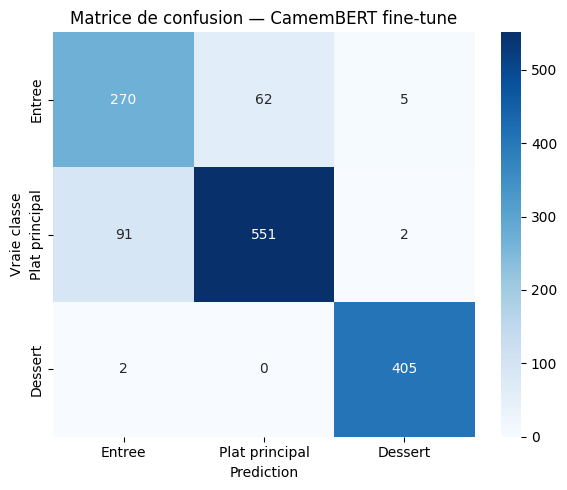

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Prediction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion — CamemBERT fine-tune")
plt.tight_layout()
plt.savefig("confusion_matrix_run4.png", dpi=150)
plt.show()
files.download("confusion_matrix_run4.png")

In [26]:
# Recap general
print("=" * 55)
print("RECAP GENERAL - tous les runs")
print("=" * 55)
recap = [
    ("Run 1  Baseline",                    0.211),
    ("Run 2  TF-IDF + SVM",                0.863),
    ("Run 3a Word2Vec + SVM",               0.844),
    ("Run 3b CamemBERT + SVM",              0.708),
    ("Run 4a TF-IDF + CamemBERT + SVM",    0.873),
    ("Run 4b TF-IDF + Word2Vec + SVM",     0.865),
    ("Run 4  CamemBERT fine-tune",          round(f1, 3)),
]
for name, score in recap:
    bar = chr(9608) * int(score * 30)
    print(f"{name:<42} {score:.3f}  {bar}")

# Sauvegarder les predictions
pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv("predictions_run4_finetune.csv", index=False)
files.download("predictions_run4_finetune.csv")

RECAP GENERAL - tous les runs
Run 1  Baseline                            0.211  ██████
Run 2  TF-IDF + SVM                        0.863  █████████████████████████
Run 3a Word2Vec + SVM                      0.844  █████████████████████████
Run 3b CamemBERT + SVM                     0.708  █████████████████████
Run 4a TF-IDF + CamemBERT + SVM            0.873  ██████████████████████████
Run 4b TF-IDF + Word2Vec + SVM             0.865  █████████████████████████
Run 4  CamemBERT fine-tune                 0.879  ██████████████████████████


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>